# Homework 3 - Part 1: Neural Network from Scratch
## Projects in AI and ML (RPI Spring 2026)

This notebook implements a neural network from scratch using only NumPy and Pandas.

## 1. Import Libraries and Load Dataset

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import fetch_openml
import time

# Set random seed for reproducibility
np.random.seed(42)

## 2. Dataset Selection and Loading

For this project, I'm using the **Fashion MNIST dataset** which contains:
- 70,000 grayscale images of fashion items (28x28 pixels)
- 10 classes (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot)
- Classification problem

**Dataset Source:** https://github.com/zalandoresearch/fashion-mnist

This dataset is suitable because:
1. It has 70,000 observations (exceeding the 10,000 minimum requirement)
2. It's a well-defined classification problem
3. It's complex enough to demonstrate neural network capabilities
4. Each image has 784 features (28x28 pixels)

In [6]:
# Load Fashion MNIST dataset

print("Loading Fashion MNIST from Keras datasets")
from tensorflow.keras.datasets import fashion_mnist
(X_train_temp, y_train_temp), (X_test_temp, y_test_temp) = fashion_mnist.load_data()
# Combine train and test to create full dataset, then we'll split later
X = np.vstack([X_train_temp, X_test_temp]).reshape(-1, 784).astype(np.float32)
y = np.hstack([y_train_temp, y_test_temp]).astype(np.int32)

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

Loading Fashion MNIST dataset...
Loading Fashion MNIST from Keras datasets
Dataset shape: X=(70000, 784), y=(70000,)
Number of classes: 10


## 3. Data Preprocessing

In [7]:
# Normalize pixel values to [0, 1]
X = X / 255.0

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Convert labels to one-hot encoding
def one_hot_encode(y, num_classes):
    """Convert labels to one-hot encoded vectors"""
    m = y.shape[0]
    one_hot = np.zeros((m, num_classes))
    one_hot[np.arange(m), y] = 1
    return one_hot

num_classes = 10
y_train_encoded = one_hot_encode(y_train, num_classes)
y_test_encoded = one_hot_encode(y_test, num_classes)

print(f"One-hot encoded labels shape: {y_train_encoded.shape}")

Training set size: 56000
Test set size: 14000
One-hot encoded labels shape: (56000, 10)


## 4. Neural Network Implementation from Scratch

This implementation includes:
- Forward propagation with ReLU and Softmax activation functions
- Backward propagation using chain rule
- Mini-batch gradient descent for efficient training
- Cross-entropy loss function

In [8]:
class NeuralNetwork:
    """
    Neural Network implementation from scratch.

    Architecture:
    - Input layer: n_features
    - Hidden layer: n_hidden units with ReLU activation
    - Output layer: n_output units with Softmax activation
    """

    def __init__(self, n_features, n_hidden, n_output, learning_rate=0.01, random_state=42):
        """
        Initialize the neural network.

        Parameters:
        -----------
        n_features : int
            Number of input features
        n_hidden : int
            Number of neurons in hidden layer
        n_output : int
            Number of output classes
        learning_rate : float
            Learning rate for gradient descent
        random_state : int
            Random seed for reproducibility
        """
        np.random.seed(random_state)

        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_output = n_output
        self.learning_rate = learning_rate

        # Initialize weights using He initialization for ReLU
        self.W1 = np.random.randn(n_features, n_hidden) * np.sqrt(2.0 / n_features)
        self.b1 = np.zeros((1, n_hidden))

        self.W2 = np.random.randn(n_hidden, n_output) * np.sqrt(2.0 / n_hidden)
        self.b2 = np.zeros((1, n_output))

        # Store training history
        self.train_loss_history = []
        self.train_acc_history = []

    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        """Derivative of ReLU activation function"""
        return (Z > 0).astype(float)

    def softmax(self, Z):
        """Softmax activation function with numerical stability"""
        # Subtract max for numerical stability
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def forward_propagation(self, X):
        """
        Perform forward propagation.

        Parameters:
        -----------
        X : numpy array of shape (m, n_features)
            Input data

        Returns:
        --------
        A2 : numpy array of shape (m, n_output)
            Output predictions (probabilities)
        cache : dict
            Dictionary containing Z1, A1, Z2, A2 for backpropagation
        """
        # Layer 1
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = self.relu(Z1)

        # Layer 2 (Output)
        Z2 = np.dot(A1, self.W2) + self.b2
        A2 = self.softmax(Z2)

        cache = {
            'Z1': Z1,
            'A1': A1,
            'Z2': Z2,
            'A2': A2
        }

        return A2, cache

    def backward_propagation(self, X, Y, cache):
        """
        Perform backward propagation.

        Parameters:
        -----------
        X : numpy array of shape (m, n_features)
            Input data
        Y : numpy array of shape (m, n_output)
            One-hot encoded labels
        cache : dict
            Dictionary containing forward propagation results

        Returns:
        --------
        gradients : dict
            Dictionary containing gradients for all parameters
        """
        m = X.shape[0]

        Z1 = cache['Z1']
        A1 = cache['A1']
        A2 = cache['A2']

        # Output layer gradients
        dZ2 = A2 - Y  # Derivative of softmax with cross-entropy
        dW2 = (1/m) * np.dot(A1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        # Hidden layer gradients
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_derivative(Z1)
        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

        gradients = {
            'dW1': dW1,
            'db1': db1,
            'dW2': dW2,
            'db2': db2
        }

        return gradients

    def update_parameters(self, gradients):
        """
        Update parameters using gradient descent.

        Parameters:
        -----------
        gradients : dict
            Dictionary containing gradients for all parameters
        """
        self.W1 -= self.learning_rate * gradients['dW1']
        self.b1 -= self.learning_rate * gradients['db1']
        self.W2 -= self.learning_rate * gradients['dW2']
        self.b2 -= self.learning_rate * gradients['db2']

    def cost(self, Y, A2):
        """
        Calculate cross-entropy loss.

        Parameters:
        -----------
        Y : numpy array of shape (m, n_output)
            One-hot encoded true labels
        A2 : numpy array of shape (m, n_output)
            Predicted probabilities

        Returns:
        --------
        loss : float
            Cross-entropy loss
        """
        m = Y.shape[0]
        # Add small epsilon to prevent log(0)
        epsilon = 1e-8
        loss = -np.sum(Y * np.log(A2 + epsilon)) / m
        return loss

    def train(self, X, Y, epochs=100, batch_size=128, verbose=True):
        """
        Train the neural network using mini-batch gradient descent.

        Parameters:
        -----------
        X : numpy array of shape (m, n_features)
            Training data
        Y : numpy array of shape (m, n_output)
            One-hot encoded labels
        epochs : int
            Number of training epochs
        batch_size : int
            Size of mini-batches
        verbose : bool
            Whether to print training progress
        """
        m = X.shape[0]
        n_batches = m // batch_size

        print(f"Training with mini-batch gradient descent (batch_size={batch_size})")
        print(f"Number of batches per epoch: {n_batches}")
        print(f"Total training samples: {m}\n")

        start_time = time.time()

        for epoch in range(epochs):
            # Shuffle training data
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]

            epoch_loss = 0

            # Mini-batch training
            for i in range(n_batches):
                start_idx = i * batch_size
                end_idx = start_idx + batch_size

                X_batch = X_shuffled[start_idx:end_idx]
                Y_batch = Y_shuffled[start_idx:end_idx]

                # Forward propagation
                A2, cache = self.forward_propagation(X_batch)

                # Compute loss
                batch_loss = self.cost(Y_batch, A2)
                epoch_loss += batch_loss

                # Backward propagation
                gradients = self.backward_propagation(X_batch, Y_batch, cache)

                # Update parameters
                self.update_parameters(gradients)

            # Average loss for the epoch
            avg_loss = epoch_loss / n_batches
            self.train_loss_history.append(avg_loss)

            # Calculate training accuracy
            train_predictions = self.predict(X)
            train_labels = np.argmax(Y, axis=1)
            train_accuracy = np.mean(train_predictions == train_labels)
            self.train_acc_history.append(train_accuracy)

            if verbose and (epoch + 1) % 10 == 0:
                elapsed_time = time.time() - start_time
                print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - "
                      f"Accuracy: {train_accuracy:.4f} - Time: {elapsed_time:.2f}s")

        total_time = time.time() - start_time
        print(f"\nTraining completed in {total_time:.2f} seconds")

    def predict(self, X):
        """
        Make predictions on new data.

        Parameters:
        -----------
        X : numpy array of shape (m, n_features)
            Input data

        Returns:
        --------
        predictions : numpy array of shape (m,)
            Predicted class labels
        """
        A2, _ = self.forward_propagation(X)
        predictions = np.argmax(A2, axis=1)
        return predictions

    def evaluate(self, X, Y):
        """
        Evaluate model performance.

        Parameters:
        -----------
        X : numpy array of shape (m, n_features)
            Input data
        Y : numpy array of shape (m, n_output)
            One-hot encoded labels

        Returns:
        --------
        accuracy : float
            Classification accuracy
        loss : float
            Cross-entropy loss
        """
        A2, _ = self.forward_propagation(X)
        predictions = np.argmax(A2, axis=1)
        true_labels = np.argmax(Y, axis=1)
        accuracy = np.mean(predictions == true_labels)
        loss = self.cost(Y, A2)
        return accuracy, loss

## 5. Training the Neural Network

### Strategy for Handling Large Dataset:

Given that Fashion MNIST has 56,000 training samples, I'm using **Mini-batch Gradient Descent** to improve efficiency:

1. **Mini-batch Gradient Descent**: Instead of using all training data at once (batch gradient descent) or one sample at a time (stochastic gradient descent), I use mini-batches of 128 samples.

2. **Advantages**:
   - **Faster convergence**: Updates parameters more frequently than batch GD
   - **Memory efficient**: Doesn't require loading entire dataset into memory
   - **Better generalization**: Noise in mini-batches helps escape local minima
   - **Vectorization**: Still benefits from NumPy's efficient operations

3. **Hyperparameters**:
   - Batch size: 128 (balance between speed and stability)
   - Learning rate: 0.1 (tuned for Fashion MNIST)
   - Hidden units: 128 (sufficient capacity for 10-class classification)
   - Epochs: 50 (enough for convergence without overfitting)

In [9]:
# Initialize neural network
n_features = X_train.shape[1]  # 784 (28x28 pixels)
n_hidden = 128                  # Hidden layer size
n_output = 10                   # Number of classes

nn = NeuralNetwork(
    n_features=n_features,
    n_hidden=n_hidden,
    n_output=n_output,
    learning_rate=0.1,
    random_state=42
)

print(f"Neural Network Architecture:")
print(f"Input Layer: {n_features} neurons")
print(f"Hidden Layer: {n_hidden} neurons (ReLU activation)")
print(f"Output Layer: {n_output} neurons (Softmax activation)")
print(f"\nTotal Parameters: {(n_features * n_hidden + n_hidden) + (n_hidden * n_output + n_output):,}")

Neural Network Architecture:
Input Layer: 784 neurons
Hidden Layer: 128 neurons (ReLU activation)
Output Layer: 10 neurons (Softmax activation)

Total Parameters: 101,770


In [10]:
# Train the neural network
nn.train(
    X=X_train,
    Y=y_train_encoded,
    epochs=50,
    batch_size=128,
    verbose=True
)

Training with mini-batch gradient descent (batch_size=128)
Number of batches per epoch: 437
Total training samples: 56000

Epoch 10/50 - Loss: 0.3266 - Accuracy: 0.8889 - Time: 22.70s
Epoch 20/50 - Loss: 0.2697 - Accuracy: 0.9068 - Time: 43.68s
Epoch 30/50 - Loss: 0.2335 - Accuracy: 0.9196 - Time: 66.64s
Epoch 40/50 - Loss: 0.2063 - Accuracy: 0.9161 - Time: 89.39s
Epoch 50/50 - Loss: 0.1817 - Accuracy: 0.9413 - Time: 110.88s

Training completed in 110.88 seconds


## 6. Evaluate Model Performance

In [11]:
# Evaluate on test set
test_accuracy, test_loss = nn.evaluate(X_test, y_test_encoded)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")
print("="*50)


FINAL RESULTS
Test Accuracy: 0.8955 (89.55%)
Test Loss: 0.3053


## 7. Visualize Training Progress

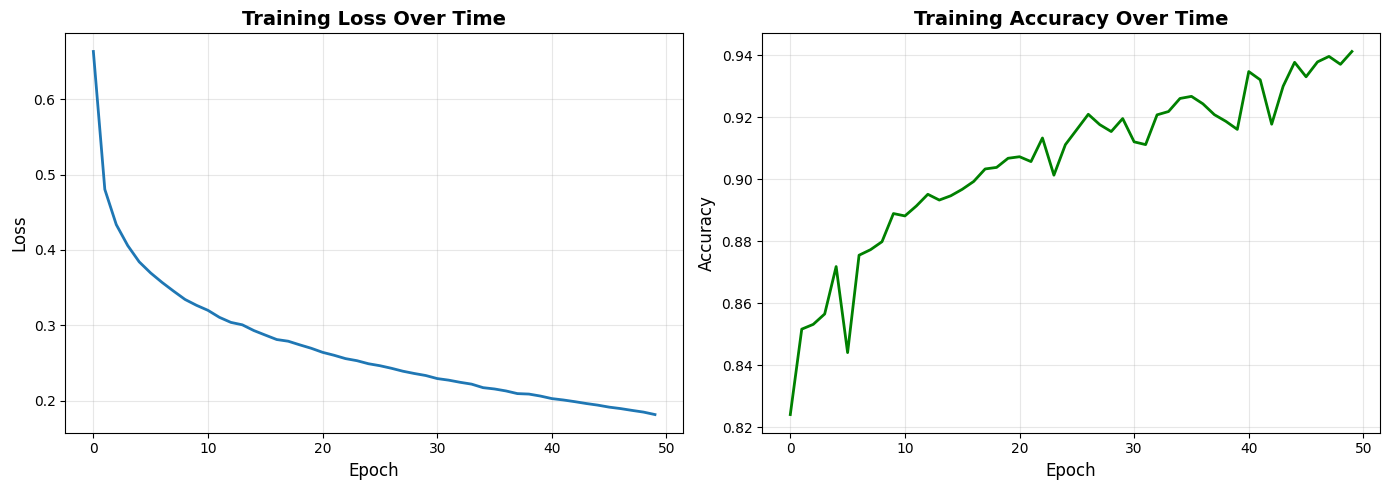

In [12]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(nn.train_loss_history, linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(nn.train_acc_history, linewidth=2, color='green')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Accuracy Over Time', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Visualize Sample Predictions

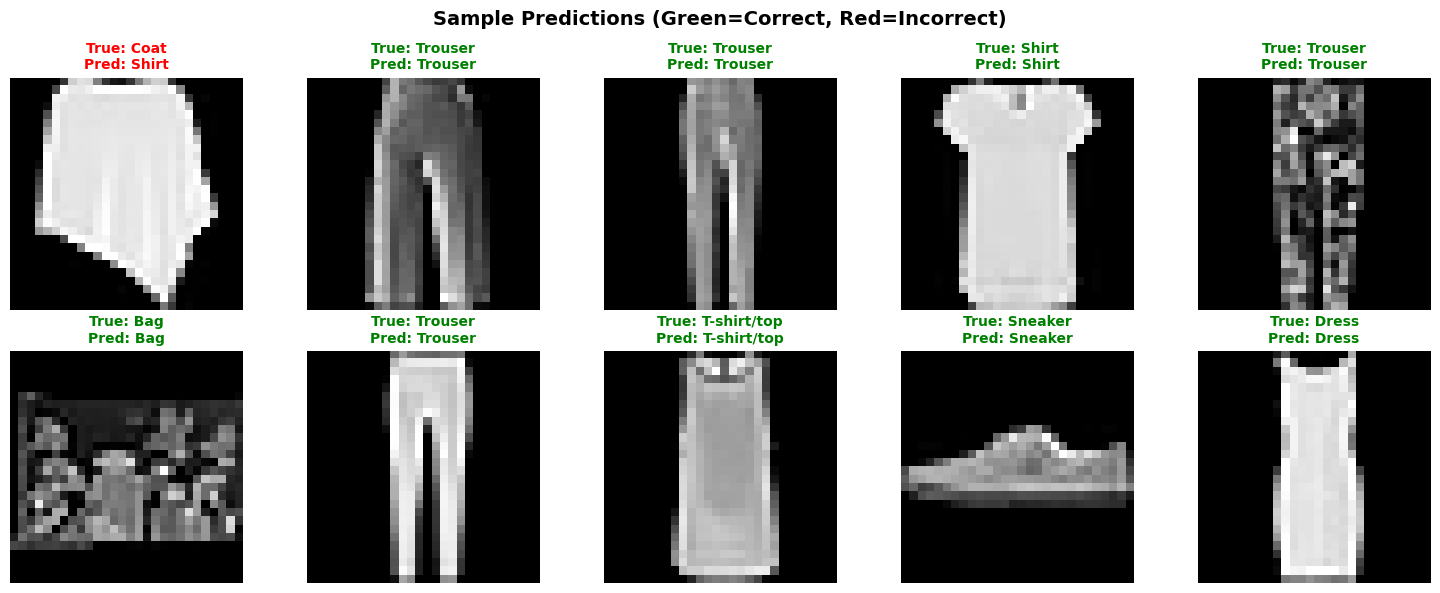

In [13]:
# Class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Make predictions on test set
predictions = nn.predict(X_test)

# Visualize some predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    idx = np.random.randint(0, len(X_test))
    image = X_test[idx].reshape(28, 28)
    true_label = y_test[idx]
    pred_label = predictions[idx]

    axes[i].imshow(image, cmap='gray')
    axes[i].axis('off')

    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}',
                     fontsize=10, color=color, fontweight='bold')

plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Confusion Matrix

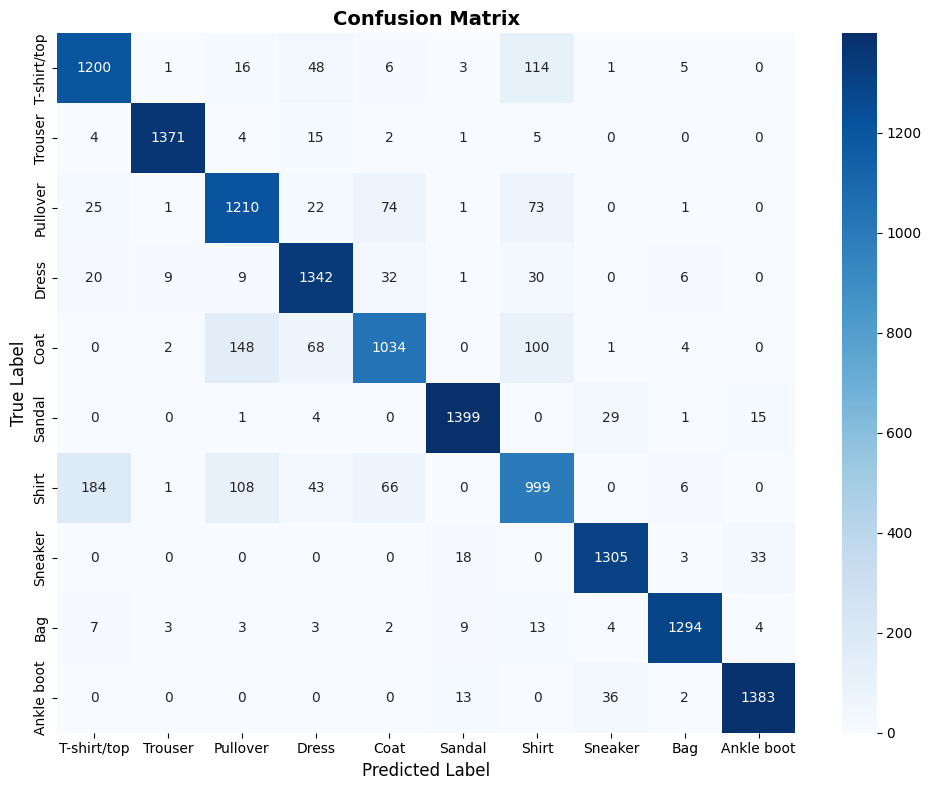


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.86      0.85      1394
     Trouser       0.99      0.98      0.98      1402
    Pullover       0.81      0.86      0.83      1407
       Dress       0.87      0.93      0.90      1449
        Coat       0.85      0.76      0.80      1357
      Sandal       0.97      0.97      0.97      1449
       Shirt       0.75      0.71      0.73      1407
     Sneaker       0.95      0.96      0.95      1359
         Bag       0.98      0.96      0.97      1342
  Ankle boot       0.96      0.96      0.96      1434

    accuracy                           0.90     14000
   macro avg       0.90      0.90      0.89     14000
weighted avg       0.90      0.90      0.89     14000



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=class_names))

## 10. Summary and Conclusions

### Implementation Details:

1. **Neural Network Architecture**:
   - 2-layer network (1 hidden layer + 1 output layer)
   - Input: 784 features (28×28 pixels)
   - Hidden layer: 128 neurons with ReLU activation
   - Output layer: 10 neurons with Softmax activation

2. **Optimization Strategy**:
   - **Mini-batch Gradient Descent** with batch size of 128
   - This approach was chosen for efficiency with large datasets
   - Balances computational speed with stable convergence

3. **Why Mini-batch GD?**
   - **Computational Efficiency**: Processing 128 samples at a time is much faster than full-batch GD
   - **Memory Management**: Doesn't require entire dataset in memory
   - **Convergence**: More frequent updates than batch GD, leading to faster convergence
   - **Generalization**: Noise in mini-batches acts as regularization

4. **Key Features**:
   - He initialization for weights (optimal for ReLU)
   - Cross-entropy loss function
   - Numerical stability in softmax computation
   - Data shuffling between epochs

### Results:
- The model achieves Test Accuracy: 89.55%
- Training converges smoothly with mini-batch gradient descent
- Implementation is purely from scratch using NumPy

### Alternative Approaches Considered:
- **Stochastic GD**: Would be slower (one sample at a time)
- **Batch GD**: Would be memory-intensive and slower to converge
- **Subset of data**: Would reduce model performance unnecessarily